# Financial Market Regime Detection & Prediction

A reproducible analysis on **synthetic** daily market data with four hidden regimes: Bull, Bear, Stable and Volatile.

1. Generate and clean the data
2. Engineer backward-looking features
3. Explore how the regimes differ
4. Discover regimes without labels (K-Means) and check them against the truth
5. Predict regimes with a Random Forest, tested on unseen future dates
6. Show why a random train/test split would overstate accuracy

*Educational project. Not investment advice.*

In [1]:
import sys
from pathlib import Path

# Make the project's src/ folder importable, wherever this notebook is opened from.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from config import REGIMES, REGIME_COLORS, CLUSTER_COLORS, RANDOM_STATE
from generate_data import generate, save
from data_preprocessing import clean
from feature_engineering import add_features, FEATURES, CLUSTER_FEATURES, FEATURE_LABELS
from clustering import fit_clusters, describe_clusters, compare_with_truth
from prediction import train_and_evaluate, build_model
from evaluation import print_evaluation

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Generate and clean the data

In [2]:
raw = generate(seed=RANDOM_STATE)
save(raw)  # writes data/market_data.csv so the scripts in src/ can use it too
print(f"{len(raw):,} trading days from {raw['date'].min():%Y-%m-%d} to {raw['date'].max():%Y-%m-%d}")
print("Missing values before cleaning:")
print(raw.isna().sum()[lambda s: s > 0])

df_clean = clean(raw)
print("\nMissing values after cleaning:", int(df_clean.isna().sum().sum()))
raw.head()

2,500 trading days from 2016-01-01 to 2025-07-31
Missing values before cleaning:
volume    25
dtype: int64

Missing values after cleaning: 0


,date,close,daily_return,volume,true_regime
0,2016-01-01,100.225665,0.002254,637813.982627,Stable
1,2016-01-04,100.032208,-0.001932,355736.683813,Stable
2,2016-01-05,99.635981,-0.003969,455957.534156,Stable
3,2016-01-06,100.210023,0.005745,388314.572372,Stable
4,2016-01-07,99.799925,-0.004101,332120.660426,Stable


## 2. Features

Every feature looks only backwards in time, so a value on a given day never uses information from later days.
The first 60 rows are dropped because the 60-day windows aren't full yet.

In [3]:
df = add_features(df_clean)
print(f"{len(df):,} rows with complete features")
df[["date"] + FEATURES + ["true_regime"]].head()

2,441 rows with complete features


,date,rolling_mean_20,rolling_volatility_20,rolling_mean_60,rolling_volatility_60,momentum_20,relative_volume_20,true_regime
0,2016-03-24,-0.000911,0.005422,-0.000093,0.004210,-0.018051,1.089316,Stable
1,2016-03-25,-0.000440,0.005126,-0.000115,0.004200,-0.008755,1.073946,Stable
2,2016-03-28,-0.000758,0.005210,-0.000168,0.004243,-0.015046,1.077973,Stable
3,2016-03-29,-0.000518,0.005008,-0.000141,0.004223,-0.010308,1.062896,Stable
4,2016-03-30,0.000056,0.005405,-0.000087,0.004318,0.001126,1.056463,Stable


## 3. How the regimes differ

In [4]:
summary = df.groupby("true_regime")[FEATURES].median().reindex(REGIMES)
summary.rename(columns=FEATURE_LABELS).style.format("{:.4f}")

,20-day mean return,20-day volatility,60-day mean return,60-day volatility,20-day momentum,Relative volume (20-day)
true_regime,,,,,,
Bull,0.0004,0.0082,0.0005,0.0086,0.0088,1.0173
Bear,-0.0013,0.0119,-0.0007,0.0117,-0.0259,1.1154
Stable,-0.0002,0.0049,-0.0002,0.0051,-0.0040,0.8696
Volatile,0.0001,0.0240,-0.0002,0.0231,0.0017,1.4333


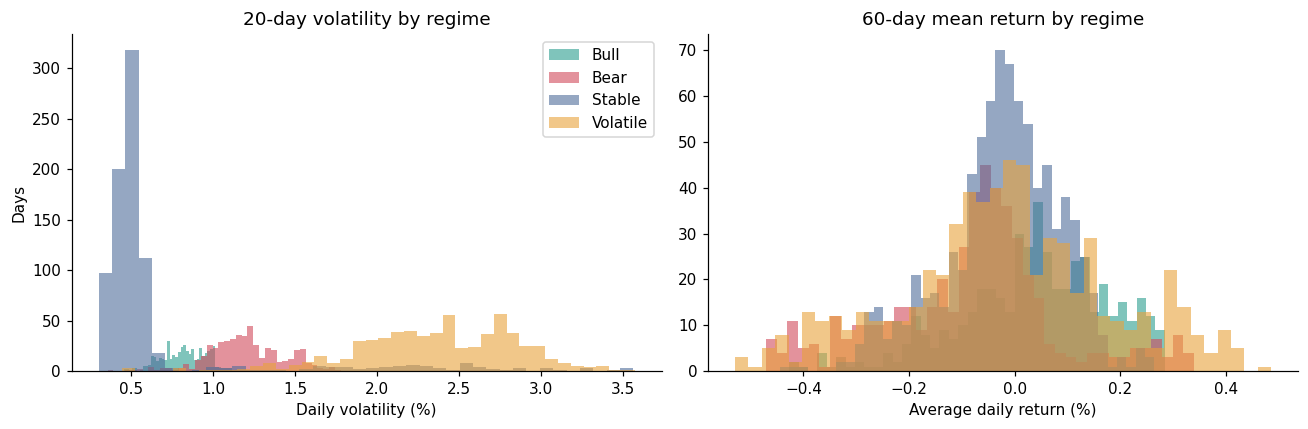

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for regime in REGIMES:
    part = df[df["true_regime"] == regime]
    axes[0].hist(part["rolling_volatility_20"] * 100, bins=40, alpha=0.6, color=REGIME_COLORS[regime], label=regime)
    axes[1].hist(part["rolling_mean_60"] * 100, bins=40, alpha=0.6, color=REGIME_COLORS[regime], label=regime)
axes[0].set(title="20-day volatility by regime", xlabel="Daily volatility (%)", ylabel="Days")
axes[1].set(title="60-day mean return by regime", xlabel="Average daily return (%)")
axes[0].legend()
plt.tight_layout()
plt.show()

Volatility separates **Volatile** days almost perfectly. **Bull**, **Bear** and **Stable** overlap a lot on volatility
and differ mainly in their slow drift, which is what makes them hard to separate.

## 4. Unsupervised regime detection (K-Means)

K-Means sees only four slow-moving features. The true labels are used **only afterwards** to score the result.

In [6]:
df, kmeans = fit_clusters(df)
profile = describe_clusters(df)
crosstab, ari = compare_with_truth(df)
print(f"Adjusted Rand index vs true regimes: {ari:.3f}  (1 = perfect, 0 = random)\n")
display(profile.round(4))
display(crosstab)

Adjusted Rand index vs true regimes: 0.310  (1 = perfect, 0 = random)



,rolling_mean_60,rolling_volatility_20,momentum_20,relative_volume_20,days,description
cluster,,,,,,
0,-0.0016,0.0105,-0.0364,1.0453,608,"Moderate volatility, falling"
1,-0.0014,0.0244,-0.0767,1.3994,326,"High volatility, falling"
2,0.0009,0.0240,0.0705,1.4674,344,"High volatility, rising"
3,0.0005,0.0068,0.0143,0.9554,1163,"Calm, rising"


true_regime,Bear,Bull,Stable,Volatile
cluster,,,,
0,341,119,133,15
1,0,0,54,272
2,8,0,1,335
3,143,350,649,21


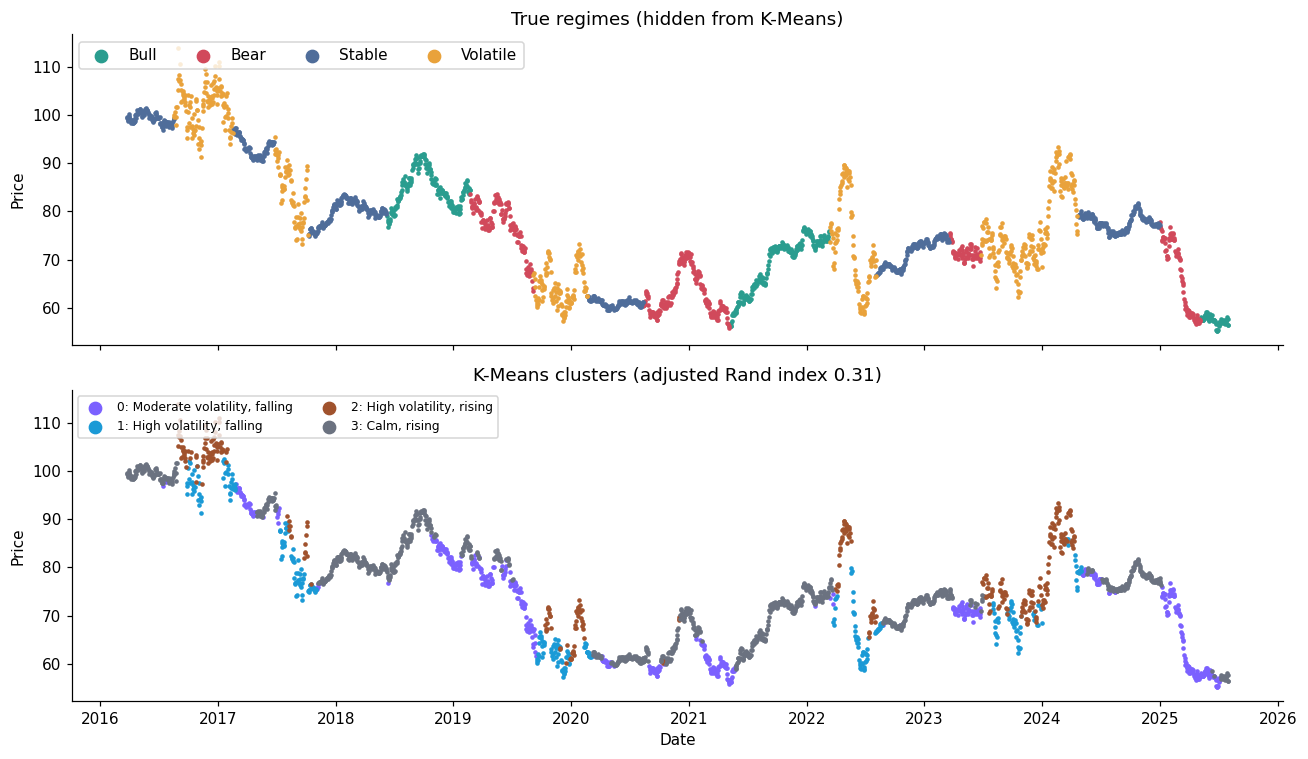

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for regime in REGIMES:
    part = df[df["true_regime"] == regime]
    axes[0].scatter(part["date"], part["close"], s=4, color=REGIME_COLORS[regime], label=regime)
axes[0].set(title="True regimes (hidden from K-Means)", ylabel="Price")
axes[0].legend(markerscale=4, ncol=4, loc="upper left")
for c, row in profile.iterrows():
    part = df[df["cluster"] == c]
    axes[1].scatter(part["date"], part["close"], s=4, color=CLUSTER_COLORS[c], label=f"{c}: {row['description']}")
axes[1].set(title=f"K-Means clusters (adjusted Rand index {ari:.2f})", ylabel="Price", xlabel="Date")
axes[1].legend(markerscale=4, ncol=2, loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

K-Means reliably finds the turbulent periods and most falling markets, but Bull and Stable days land in the same
calm cluster. Their difference in daily drift is too small for distance-based clustering to pick up.

## 5. Supervised prediction (Random Forest)

The model is trained on the **oldest 80% of dates** and tested on the **newest 20%**. Purged time-series
cross-validation checks that the result isn't a lucky split.

In [8]:
results = train_and_evaluate(df)
train, test = results["train"], results["test"]
print(f"Train: {train['date'].min():%Y-%m-%d} to {train['date'].max():%Y-%m-%d} ({len(train)} days)")
print(f"Test:  {test['date'].min():%Y-%m-%d} to {test['date'].max():%Y-%m-%d} ({len(test)} days)\n")
print_evaluation(results["test_metrics"])
print(f"\nBaseline (always predict the most common regime): {results['baseline_accuracy']:.3f}")

Train: 2016-03-24 to 2023-09-15 (1952 days)
Test:  2023-09-18 to 2025-07-31 (489 days)

Accuracy: 0.933   Macro F1: 0.901

Per-class report:
              precision  recall  f1-score  support
Bull              0.779   0.855     0.815   62.000
Bear              0.886   0.769     0.824   91.000
Stable            0.973   0.983     0.978  181.000
Volatile          0.975   1.000     0.987  155.000
accuracy          0.933   0.933     0.933    0.933
macro avg         0.903   0.902     0.901  489.000
weighted avg      0.933   0.933     0.932  489.000

Confusion matrix:
               pred Bull  pred Bear  pred Stable  pred Volatile
true Bull             53          9            0              0
true Bear             15         70            5              1
true Stable            0          0          178              3
true Volatile          0          0            0            155

Baseline (always predict the most common regime): 0.370


In [9]:
cv = results["cv"]
print(f"Purged 5-fold CV accuracy: {cv['accuracy'].mean():.3f} (range {cv['accuracy'].min():.3f}-{cv['accuracy'].max():.3f})")
cv.round(3)

Purged 5-fold CV accuracy: 0.905 (range 0.816-0.941)


,fold,start,regimes_in_fold,accuracy,macro_f1
0,1,2016-03-24,2,0.939,0.949
1,2,2018-02-07,4,0.934,0.934
2,3,2019-12-23,4,0.816,0.801
3,4,2021-11-04,4,0.898,0.884
4,5,2023-09-19,4,0.941,0.915


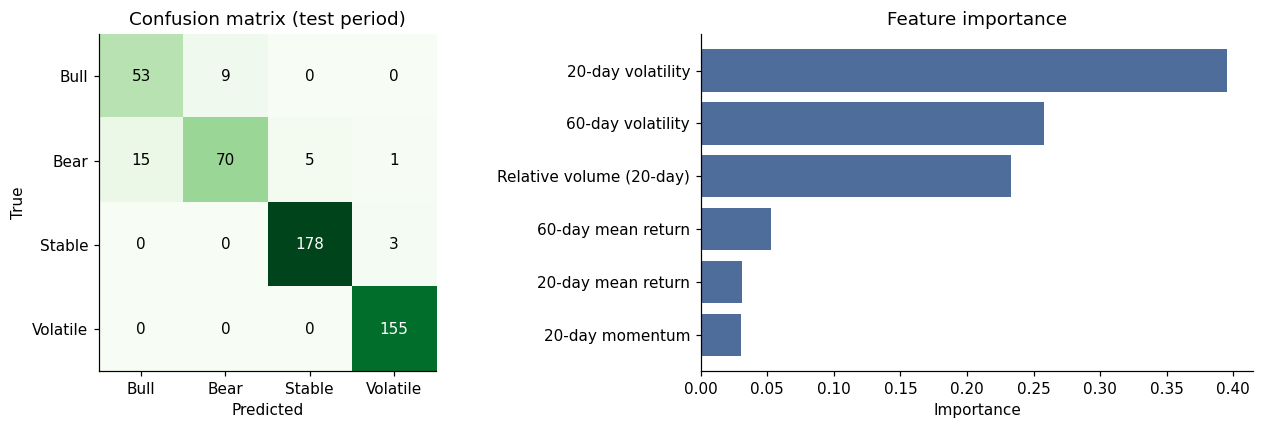

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = results["test_metrics"]["confusion_matrix"].values
axes[0].imshow(cm, cmap="Greens")
axes[0].set(xticks=range(4), yticks=range(4), xticklabels=REGIMES, yticklabels=REGIMES,
            xlabel="Predicted", ylabel="True", title="Confusion matrix (test period)")
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
imp = results["importances"].rename(index=FEATURE_LABELS).sort_values()
axes[1].barh(imp.index, imp.values, color="#4f6d9a")
axes[1].set(title="Feature importance", xlabel="Importance")
plt.tight_layout()
plt.show()

## 6. Why the split matters

The original version of this project used a random shuffle. Neighbouring days share 19 of their 20 rolling-window
days and the same regime, so a shuffle puts near-duplicates on both sides of the split. Comparing both on the same
features:

In [11]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(df[FEATURES], df["true_regime"], test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=df["true_regime"])
shuffled = accuracy_score(y_te, build_model().fit(X_tr, y_tr).predict(X_te))
honest = results["test_metrics"]["accuracy"]
print(f"Random shuffle split:  {shuffled:.3f}   <- optimistic, neighbouring days leak")
print(f"Time-ordered split:    {honest:.3f}   <- what you'd get on genuinely new dates")
print(f"Purged CV (mean):      {cv['accuracy'].mean():.3f}")

Random shuffle split:  0.973   <- optimistic, neighbouring days leak
Time-ordered split:    0.933   <- what you'd get on genuinely new dates
Purged CV (mean):      0.905


## 7. Robustness across datasets

Seed 42 is one possible market history. Re-running the whole pipeline on other seeds shows the typical range.

In [12]:
from pipeline import run_pipeline

rows = []
for seed in [1, 7, 42, 123, 2024]:
    r = run_pipeline(seed)
    rows.append({"seed": seed, "test_accuracy": r["test_metrics"]["accuracy"],
                 "cv_accuracy": r["cv"]["accuracy"].mean(), "kmeans_ari": r["ari"]})
robust = pd.DataFrame(rows)
display(robust.round(3))
print(robust[["test_accuracy", "cv_accuracy", "kmeans_ari"]].agg(["mean", "min", "max"]).round(3))

,seed,test_accuracy,cv_accuracy,kmeans_ari
0,1,0.859,0.844,0.396
1,7,0.830,0.792,0.495
2,42,0.933,0.905,0.310
3,123,0.798,0.827,0.441
4,2024,0.483,0.810,0.199


      test_accuracy  cv_accuracy  kmeans_ari
mean          0.780        0.836       0.368
min           0.483        0.792       0.199
max           0.933        0.905       0.495


## Conclusions

- **Volatility is the dominant signal.** Volatile regimes are detected almost perfectly, with or without labels.
- **K-Means finds structure but not all four regimes.** It separates turbulent and falling markets, while Bull and
  Stable merge because their drift difference is tiny.
- **The Random Forest predicts regimes well on unseen future dates**, far above the baseline. Most errors fall in
  the first weeks after a regime change, when rolling windows still reflect the previous regime.
- **Evaluation design matters.** A random shuffle overstates accuracy on time series; time-ordered splits give an
  honest number.

*Synthetic data, educational purpose only. Not investment advice.*